# 04 · Simulated truth: the same pipeline where the true field is known

On real data the radar is the target, and the radar is not the truth (at Gothenburg's gauges it
is worse than the gauges themselves; see `projects/maps/multisensor`). `core.simulation` makes
storms whose rain is known everywhere, observes them with simulated links (power law, noise,
quantization, wet antenna, baseline), gauges and a radar, and returns them in the same structures
as the real networks. `ml.from_synthetic` turns a set of simulated storms into the same dataset as
notebook 01, with the **true field as the target** and the simulated radar kept alongside.

A method can therefore be checked here first: does it beat the baselines against the truth, and
does scoring against the radar rank the methods the same way as scoring against the truth?

Each simulated storm is one event: 3 hours at 10-minute steps on a 64 km x 64 km domain (1 km
cells), with its own rain model, motion and link network (60-120 links). Units: mm per 10 minutes;
wet = 0.1 mm per 10 minutes (0.6 mm/h).

**Runtime:** about four minutes, three of them simulating the storms.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")    # PyTorch and other OpenMP users in one process

import sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects/maps/learned_2d/src"))

from core.data_paths import OUTPUTS
from core.maps import learning as ml

CACHE = OUTPUTS / "_learned_2d"          # generated files, not tracked
SPLIT_COLORS = {"train": "#3b6fb6", "val": "#e08a2e", "test": "#c03b3b"}
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
T0 = time.time()
from core.maps import map_skill as sk
from core.simulation.scenario import Scenario
from core.maps.mergeplg_methods import fit_radar_variogram
from learned_2d.baselines import baseline_maps

## 1. Twelve simulated storms, one dataset

In [2]:
MODELS = ["convective_cells", "clustered_storms", "squall_line", "stratiform_matern", "banded_anisotropic", "frontal"]
t = time.time()
cases = [Scenario(model=MODELS[k % len(MODELS)], flow="uniform", n=128, dx_km=0.5, duration_min=180,
                  interval_min=10, n_links=(60, 120), n_gauges=15, seed=k,
                  start=f"2026-07-{k + 1:02d} 12:00").run() for k in range(12)]
print(f"{len(cases)} storms simulated in {time.time() - t:.0f} s")
sim = ml.from_synthetic(cases, event_ids=[f"{MODELS[k % len(MODELS)]}_{k}" for k in range(12)])
sim[["event_split"]].to_dataframe().assign(
    links=[c.links.sizes["link"] for c in cases], mean_truth_mm=[float(c.truth.mean()) for c in cases]).round(3)

12 storms simulated in 184 s


,event_split,links,mean_truth_mm
event,,,
convective_cells_0,train,111,0.433
clustered_storms_1,test,88,0.780
squall_line_2,train,111,0.273
stratiform_matern_3,train,109,0.283
banded_anisotropic_4,train,104,0.300
frontal_5,train,100,0.175
convective_cells_6,val,87,0.199
clustered_storms_7,train,117,0.535
squall_line_8,test,103,0.380


## 2. Baselines against the truth, and against the radar

No training here, so the baselines are scored on every event; the split is kept in the dataset
for a learned method. The radar is scored too: against the truth it is one more estimate.

In [3]:
# each storm has its own network: score each hour on the cells within 2 km of *that storm's* links
near = xr.zeros_like(sim.target, dtype=bool)
for ev in sim.event.values:
    own = ml.link_rain_of(sim).sel(link=[l for l in sim.link.values if l.startswith(ev + "/")])
    near[sim.event_id.values == ev] = (ml.distance_to_links(ml.Grid(sim.lat.values, sim.lon.values), own) <= 2.0).values
truth = sim.target.where(near)
variogram = fit_radar_variogram(sim.radar.sel(time=sim.split == "train"))      # from the simulated radar, as on real data
t = time.time()
maps = baseline_maps(sim, variogram)
print(f"baselines in {time.time() - t:.0f} s; variogram range {variogram['range'] / 1000:.1f} km, "
      f"nugget share {variogram['nugget']:.2f}; scored cell-steps {int(near.sum())}")
vs_truth = sk.skill_table({**maps, "radar": sim.radar}, truth, event=sim.event_id, gauges=sim.gauges, threshold=0.1)
pd.set_option("display.precision", 3)
vs_truth

baselines in 37 s; variogram range 12.6 km, nugget share 0.00; scored cell-steps 97542


,n,rmse,mae,bias,pcc,pcc_step,event_bias,event_abs_rel_error,pod,far,csi,gauge_n,gauge_rmse,gauge_mae,gauge_bias,gauge_pcc
method,,,,,,,,,,,,,,,,
idw,97542,0.486,0.191,1.212e-04,0.816,0.688,-0.016,0.121,0.873,0.315,0.622,1098,1.079,0.426,0.032,0.434
ok,97542,0.390,0.153,3.548e-03,0.886,0.742,0.040,0.140,0.846,0.262,0.650,1098,0.818,0.377,-0.005,0.578
gmz,97542,0.462,0.182,1.009e-03,0.836,0.702,0.002,0.130,0.868,0.304,0.629,1098,1.068,0.422,0.027,0.435
radar,97542,0.616,0.206,-7.776e-03,0.711,0.716,-0.162,0.110,0.836,0.186,0.703,1098,0.722,0.248,-0.035,0.697


In [4]:
vs_radar = sk.skill_table(maps, sim.radar.where(near), event=sim.event_id, threshold=0.1)
pd.DataFrame({"RMSE vs truth": vs_truth.rmse.drop("radar"), "RMSE vs radar": vs_radar.rmse,
              "PCC vs truth": vs_truth.pcc.drop("radar"), "PCC vs radar": vs_radar.pcc,
              "rank vs truth": vs_truth.rmse.drop("radar").rank(), "rank vs radar": vs_radar.rmse.rank()})

,RMSE vs truth,RMSE vs radar,PCC vs truth,PCC vs radar,rank vs truth,rank vs radar
method,,,,,,
idw,0.486,0.639,0.816,0.614,3.0,3.0
ok,0.390,0.623,0.886,0.665,1.0,1.0
gmz,0.462,0.637,0.836,0.625,2.0,2.0


## 3. One storm: truth, radar and baselines

Totals over the storm; thin grey lines: the storm's links.

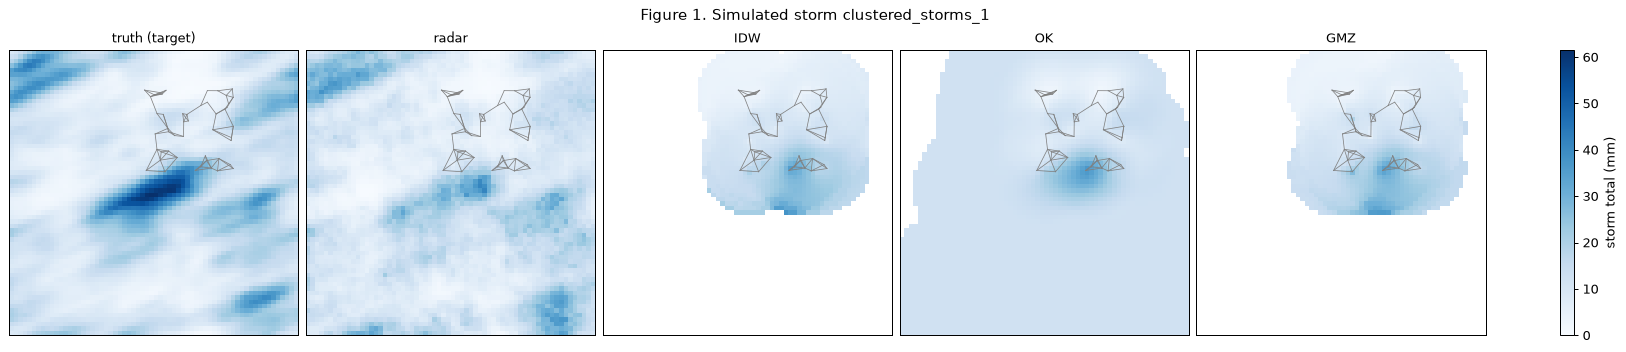

runtime 232 s


In [5]:
ev = sim.event.values[int(np.argmax([float(c.truth.std()) for c in cases]))]
sel = sim.event_id == ev
fields = {"truth (target)": sim.target, "radar": sim.radar, **{k.upper(): m for k, m in maps.items()}}
vmax = float(sim.target.sel(time=sel).sum("time").max())
links = ml.link_rain_of(sim).sel(link=[l for l in sim.link.values if l.startswith(ev + "/")])
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), constrained_layout=True)
for ax, (name, m) in zip(axes, fields.items()):
    pm = ax.pcolormesh(sim.lon, sim.lat, m.sel(time=sel).sum("time", min_count=1), cmap="Blues", vmin=0, vmax=vmax, shading="auto")
    for la0, lo0, la1, lo1 in zip(links.site_0_lat.values, links.site_0_lon.values, links.site_1_lat.values, links.site_1_lon.values):
        ax.plot([lo0, lo1], [la0, la1], color="0.5", lw=0.6)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(pm, ax=axes.tolist(), label="storm total (mm)")
fig.suptitle(f"Figure 1. Simulated storm {ev}"); plt.show()
print(f"runtime {time.time() - T0:.0f} s")

## Your method goes here

The simulated dataset has the same layout as the real one, so a model trained and scored in
notebook 03 runs here unchanged: `ml.arrays(sim, "train")` for a CNN, `ml.link_rain_of(sim)` for a
graph model, and `sk.skill_table(..., sim.target, ...)` against the truth. More storms, other rain
models, denser or sparser networks and noisier links are parameters of `core.simulation.scenario.Scenario`
(`random_scenario(seed)` draws all of them at random).